# Multilingual Audio Language Classification

End-to-end pipeline: preprocessing → dual feature extraction (58-D / 78-D) →
baseline (RF/SVM) + modern (Wav2Vec2 XLSR) + optional Federated Learning
simulation → evaluation → comparison.

**Assumed folder layout** (matches the multilingual dataset audited earlier):

```
/content/drive/MyDrive/multilingual_audio_dataset/
    Bengali/    *.wav or *.mp3
    Gujarati/
    Kannada/
    Konkani/
    Malayalam/
    Marathi/
    Odia/
    Tamil/
    Telugu/
```

Each top-level subfolder name is treated as the **language label**.


## 0. Setup

In [1]:
# Installs (Colab-safe, quiet)
!pip install -q librosa soundfile noisereduce transformers torch torchaudio \
    scikit-learn matplotlib seaborn pandas tqdm
!apt-get -y install ffmpeg -q > /dev/null


In [15]:
from google.colab import drive
drive.mount('/content/drive')

SOURCE_ROOT = "/content/drive/MyDrive/Audio_dataset"
WORK_DIR = "/content/work"

import os
os.makedirs(WORK_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import os, sys, glob, json, time, math, warnings, traceback
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import noisereduce as nr

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

TARGET_SR = 16000


Using device: cuda


In [13]:
!ls /content/drive/MyDrive/

'1000523794 (1).pdf'
'1000523794 (2).pdf'
 1000523794.pdf
 Audio_dataset
'CoCuricular _Activity _Rohit Banerjee.pdf'
'CoCurricular_Activity_Sania Parveen .pdf'
'Colab Notebooks'
 DOC-20260519-WA0057..pdf
'Extra_Caricular_Activity _Rohit Banerjee.pdf'
'Extra _Curricular_Activity_SaniaParveen.pdf'
 IMG-20260304-WA0037.jpg
 IMG_20260331_124535.jpg
 IMG_20260427_235219.jpg
 IMG-20260519-WA0141.jpg
 Rohit_Banerjee.jpeg
'Sania Parveen _Cocuricular_Activity.pdf'
'Sania Parveen Extracurricular activities .pdf'
'Screenshot_2026-04-04-19-49-17-23_944a2809ea1b4cda6ef12d1db9048ed3 (1).jpg'
 Screenshot_2026-04-04-19-49-17-23_944a2809ea1b4cda6ef12d1db9048ed3.jpg


## STEP 1 — Data Preprocessing (mandatory)

For every audio file we:
1. Load + convert to mono `.wav` (any input format librosa/ffmpeg can read).
2. Resample to **16000 Hz**.
3. Apply **noise reduction** (`noisereduce`, spectral-gating).
4. Remove **DC offset** — we measure the offset in dB and always zero-center
   the signal; files whose raw offset is at/above the -20 dB threshold are
   flagged in the log as "significant DC correction applied" (interpretation
   note: the spec's "below 20 dB" is ambiguous about direction, so we treat
   -20 dB as the flagging threshold and always remove the offset regardless,
   which is the safe/standard behavior).
5. Apply **Voice Activity Detection** — energy-based silence trimming
   (`librosa.effects.trim`) to cut leading/trailing silence.
6. **Skip corrupted/unreadable files**, logging the reason.

Every step is logged so you can audit exactly what happened to each file.


In [16]:
def find_audio_files(root, exts=(".wav", ".mp3", ".flac", ".ogg", ".m4a")):
    """Recursively collect audio files grouped by top-level language folder."""
    root = Path(root)
    files_by_lang = defaultdict(list)
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if Path(fn).suffix.lower() in exts:
                full_path = Path(dirpath) / fn
                rel = full_path.relative_to(root)
                lang = rel.parts[0] if len(rel.parts) > 1 else "ROOT"
                files_by_lang[lang].append(full_path)
    return files_by_lang


def preprocess_file(path, target_sr=TARGET_SR):
    """
    Returns (audio_array, log_dict) on success.
    Raises an Exception (caught by caller) on failure -> file gets skipped.
    """
    log = {"file": str(path)}

    # 1+2: load + resample + force mono
    y, sr = librosa.load(str(path), sr=target_sr, mono=True)
    if y is None or len(y) == 0:
        raise ValueError("Empty or unreadable audio")
    log["orig_len_sec"] = round(len(y) / target_sr, 3)

    # 3: noise reduction (spectral gating, uses a short leading slice as noise profile)
    try:
        y = nr.reduce_noise(y=y, sr=target_sr)
    except Exception as e:
        log["noise_reduction_warning"] = str(e)

    # 4: DC offset removal
    dc_offset = float(np.mean(y))
    dc_db = 20 * np.log10(abs(dc_offset) + 1e-12)
    y = y - dc_offset
    log["dc_offset_db"] = round(dc_db, 2)
    log["dc_flagged"] = bool(dc_db >= -20)  # flagged if offset is "large" (>= -20dB)

    # 5: VAD -> trim leading/trailing silence (energy-based)
    y_trimmed, _ = librosa.effects.trim(y, top_db=25)
    if len(y_trimmed) < target_sr * 0.1:  # guard: too short after trim (<100ms) -> keep untrimmed
        log["vad_warning"] = "trim produced <100ms audio, kept untrimmed"
    else:
        y = y_trimmed
    log["final_len_sec"] = round(len(y) / target_sr, 3)

    if len(y) < target_sr * 0.2:  # final guard: reject near-empty files (<200ms)
        raise ValueError("Audio too short after preprocessing (<200ms)")

    return y.astype(np.float32), log


In [17]:
# --- Run preprocessing over the whole dataset, cache results to disk ---

files_by_lang = find_audio_files(SOURCE_ROOT)
total_files = sum(len(v) for v in files_by_lang.values())
print(f"Found {total_files} audio files across {len(files_by_lang)} languages: "
      f"{sorted(files_by_lang.keys())}")

PROCESSED_DIR = Path(WORK_DIR) / "processed_wav"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

preprocess_logs = []
skipped_files = []
manifest = []  # list of dicts: {path, label}

for lang, paths in files_by_lang.items():
    lang_dir = PROCESSED_DIR / lang
    lang_dir.mkdir(parents=True, exist_ok=True)
    for p in tqdm(paths, desc=f"Preprocessing {lang}"):
        try:
            y, log = preprocess_file(p)
            log["language"] = lang
            preprocess_logs.append(log)

            out_path = lang_dir / (Path(p).stem + ".wav")
            sf.write(out_path, y, TARGET_SR, subtype="PCM_16")
            manifest.append({"path": str(out_path), "language": lang})
        except Exception as e:
            skipped_files.append({"file": str(p), "language": lang, "error": str(e)})

print(f"\nPreprocessed OK: {len(manifest)}")
print(f"Skipped (corrupted/unreadable): {len(skipped_files)}")

pd.DataFrame(preprocess_logs).to_csv(f"{WORK_DIR}/preprocess_log.csv", index=False)
pd.DataFrame(skipped_files).to_csv(f"{WORK_DIR}/skipped_files_log.csv", index=False)
manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv(f"{WORK_DIR}/manifest.csv", index=False)

print("\nLabel distribution after preprocessing:")
print(manifest_df["language"].value_counts())


Found 9347 audio files across 9 languages: ['Bengali', 'Gujarati', 'Kannada', 'Malayalam', 'Marathi', 'Telugu', 'konkani', 'odia', 'tamil']


Preprocessing Bengali:   0%|          | 0/1016 [00:00<?, ?it/s]

Preprocessing Gujarati:   0%|          | 0/1000 [00:00<?, ?it/s]

Preprocessing Kannada:   0%|          | 0/1000 [00:00<?, ?it/s]

Preprocessing Malayalam:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Preprocessing tamil:   0%|          | 0/1810 [00:00<?, ?it/s]

Preprocessing Telugu:   0%|          | 0/448 [00:00<?, ?it/s]

Preprocessing odia:   0%|          | 0/1664 [00:00<?, ?it/s]

Preprocessing konkani:   0%|          | 0/400 [00:00<?, ?it/s]


Preprocessed OK: 9347
Skipped (corrupted/unreadable): 0

Label distribution after preprocessing:
language
tamil        1810
odia         1664
Bengali      1016
Marathi      1009
Gujarati     1000
Malayalam    1000
Kannada      1000
Telugu        448
konkani       400
Name: count, dtype: int64


## STEP 2 — Feature Extraction (mandatory)

### Dimension inconsistency in the original spec — found and fixed

The spec's 78-D set lists: `MFCC(13) + Delta(13) + Delta-Delta(13) + Chroma(12)
+ SpectralContrast(7) + Chroma(19)`.

Two problems, documented here rather than silently "fixed":

1. **Arithmetic error**: `13+13+13+12+7+19 = 77`, not 78 — one dimension short.
2. **Duplicate feature category**: Chroma appears twice with two different
   dimensionalities (12 and 19). Standard `librosa` chroma (`chroma_stft`) is
   **12-dimensional**, so a "19-D chroma" is non-standard on its own.

**Resolution used in this notebook** (kept consistent across both feature sets):

- Standard chroma block = `chroma_stft` mean, **12-D**.
- "Extended chroma" block (to satisfy the spec's Chroma(19) entries) =
  `chroma_stft` mean (12) + `tonnetz` mean (6) + spectral centroid mean (1)
  = **19-D**. This is used wherever the spec says `Chroma(19)`.
- To close the 77→78 gap for the 78-D set, we add **1** extra scalar
  (zero-crossing-rate mean) — clearly logged as `zcr_pad (1)`.

Final, verified dimensions:

| Feature Set | Composition | Total |
|---|---|---|
| **58-D** | MFCC(13) + Delta(13) + Delta-Delta(13) + ExtendedChroma(19) | 58 |
| **78-D** | MFCC(13) + Delta(13) + Delta-Delta(13) + Chroma(12) + SpectralContrast(7) + ExtendedChroma(19) + ZCR pad(1) | 78 |

Both totals are asserted in code below — the pipeline will raise an error
rather than silently proceed if a mismatch ever occurs.


In [18]:
def extract_base_blocks(y, sr=TARGET_SR):
    """Shared building blocks reused by both feature sets."""
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    delta = librosa.feature.delta(mfcc, order=1)
    delta2 = librosa.feature.delta(mfcc, order=2)

    chroma_std = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12)   # 12-D
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)  # 6-D
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)             # 1-D

    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)    # 7-D
    zcr = librosa.feature.zero_crossing_rate(y)                         # 1-D

    def m(x):
        return np.mean(x, axis=1)

    blocks = {
        "mfcc": m(mfcc),                 # 13
        "delta": m(delta),               # 13
        "delta2": m(delta2),             # 13
        "chroma12": m(chroma_std),       # 12
        "tonnetz6": m(tonnetz),          # 6
        "centroid1": m(centroid),        # 1
        "spectral_contrast7": m(spectral_contrast),  # 7
        "zcr1": m(zcr),                  # 1
    }
    return blocks


def extended_chroma_19(blocks):
    """Chroma(12) + Tonnetz(6) + Centroid(1) = 19-D, standing in for the
    spec's non-standard 'Chroma(19)' entries."""
    return np.concatenate([blocks["chroma12"], blocks["tonnetz6"], blocks["centroid1"]])


def extract_58d(y, sr=TARGET_SR):
    b = extract_base_blocks(y, sr)
    vec = np.concatenate([b["mfcc"], b["delta"], b["delta2"], extended_chroma_19(b)])
    assert vec.shape[0] == 58, f"58-D feature vector has wrong size: {vec.shape[0]}"
    return vec


def extract_78d(y, sr=TARGET_SR):
    b = extract_base_blocks(y, sr)
    vec = np.concatenate([
        b["mfcc"], b["delta"], b["delta2"],
        b["chroma12"], b["spectral_contrast7"],
        extended_chroma_19(b),
        b["zcr1"],
    ])
    assert vec.shape[0] == 78, f"78-D feature vector has wrong size: {vec.shape[0]}"
    return vec


In [19]:
# --- Extract both feature sets for every preprocessed file ---

feat58, feat78, labels, kept_paths = [], [], [], []
feature_errors = []

for row in tqdm(manifest, desc="Extracting features"):
    p, lang = row["path"], row["language"]
    try:
        y, sr = librosa.load(p, sr=TARGET_SR, mono=True)
        f58 = extract_58d(y, sr)
        f78 = extract_78d(y, sr)
        feat58.append(f58)
        feat78.append(f78)
        labels.append(lang)
        kept_paths.append(p)
    except Exception as e:
        feature_errors.append({"file": p, "language": lang, "error": str(e)})

X58 = np.vstack(feat58)
X78 = np.vstack(feat78)
y_labels = np.array(labels)

print("X58 shape:", X58.shape)
print("X78 shape:", X78.shape)
print("Feature extraction errors:", len(feature_errors))

pd.DataFrame(feature_errors).to_csv(f"{WORK_DIR}/feature_extraction_errors.csv", index=False)

le = LabelEncoder()
y_enc = le.fit_transform(y_labels)
print("Classes:", list(le.classes_))


Extracting features:   0%|          | 0/9347 [00:00<?, ?it/s]

X58 shape: (9346, 58)
X78 shape: (9346, 78)
Feature extraction errors: 1
Classes: [np.str_('Bengali'), np.str_('Gujarati'), np.str_('Kannada'), np.str_('Malayalam'), np.str_('Marathi'), np.str_('Telugu'), np.str_('konkani'), np.str_('odia'), np.str_('tamil')]


## STEP 3 & 4 — Model Training (modern approach) on both feature sets

**Baseline**: RandomForest (also try SVM — RF is used as the reported
baseline since it's typically stronger on small tabular feature sets like
these, but SVM code is included and easy to swap in).

**Modern model (mandatory)**: Wav2Vec2 embeddings. Since this is a
**multilingual** task (9 Indian languages), we use
`facebook/wav2vec2-large-xlsr-53` — a multilingually pretrained XLSR model —
rather than the English-only `wav2vec2-base`, which is the actual "modern
approach" upgrade for this task (a plain English wav2vec2-base would be a
poor encoder for non-English speech). Embeddings = mean-pooled last hidden
state, fed into a Logistic Regression / MLP classifier.

**GPU/CPU fallback**: the notebook auto-detects whether a GPU runtime is
available (`torch.cuda.is_available()`). On GPU it uses the full
`wav2vec2-large-xlsr-53`. On CPU (e.g. Colab's free tier without a GPU
runtime) it automatically switches to the smaller `wav2vec2-xls-r-300m`
(still multilingual) and trims each clip to 5s instead of 10s, so the full
run actually finishes instead of stalling for hours. If you have GPU access,
enable it via **Runtime > Change runtime type > T4 GPU** before running for
the best/most comparable numbers.

**Optional advanced model**: Federated Learning simulation (preferred, per
spec) — one simulated client per language folder, FedAvg over a small MLP
trained on the Wav2Vec2 embeddings.

All three are trained separately on the **58-D** and **78-D** handcrafted
feature sets where applicable. Wav2Vec2 operates on raw audio, not the
handcrafted vectors — see the note in Step 6 on how it's still placed into
both rows of the comparison table for direct comparability.


In [20]:
def split_80_20(X, y, seed=42):
    return train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)

# 80/20 splits for each feature set (same seed -> same underlying files split
# the same way, so results across 58-D vs 78-D are directly comparable)
X58_tr, X58_te, y58_tr, y58_te = split_80_20(X58, y_enc)
X78_tr, X78_te, y78_tr, y78_te = split_80_20(X78, y_enc)

# scale features (helps SVM/MLP; RF is scale-invariant but harmless)
scaler58 = StandardScaler().fit(X58_tr)
scaler78 = StandardScaler().fit(X78_tr)
X58_tr_s, X58_te_s = scaler58.transform(X58_tr), scaler58.transform(X58_te)
X78_tr_s, X78_te_s = scaler78.transform(X78_tr), scaler78.transform(X78_te)

print("58-D split:", X58_tr.shape, X58_te.shape)
print("78-D split:", X78_tr.shape, X78_te.shape)


58-D split: (7476, 58) (1870, 58)
78-D split: (7476, 78) (1870, 78)


In [21]:
# --- Baseline: RandomForest (SVM alternative included, commented) ---

def train_random_forest(X_tr, y_tr):
    clf = RandomForestClassifier(n_estimators=300, max_depth=None,
                                  random_state=42, n_jobs=-1)
    clf.fit(X_tr, y_tr)
    return clf

# Optional SVM baseline (swap in by calling this instead of RF):
def train_svm(X_tr, y_tr):
    clf = SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42)
    clf.fit(X_tr, y_tr)
    return clf

rf_58 = train_random_forest(X58_tr_s, y58_tr)
rf_78 = train_random_forest(X78_tr_s, y78_tr)
print("RandomForest trained on 58-D and 78-D feature sets.")


RandomForest trained on 58-D and 78-D feature sets.


In [22]:
# --- Modern model: Wav2Vec2 (multilingual XLSR) embeddings ---
#
# GPU/CPU fallback: wav2vec2-large-xlsr-53 (~1.2GB, 24 transformer layers) is
# comfortable on a Colab GPU runtime but slow-to-impractical on CPU across a
# multi-thousand-file dataset. If no GPU is detected, we automatically drop
# to a much smaller multilingual checkpoint and trim audio harder, trading
# some embedding quality for a runtime that actually finishes on CPU.

if DEVICE == "cuda":
    WAV2VEC2_MODEL_NAME = "facebook/wav2vec2-large-xlsr-53"
    W2V_MAX_SECONDS = 10
    print("GPU detected -> using full multilingual XLSR-53 model.")
else:
    # ~95M params vs ~300M+ for xlsr-53 -- still multilingual (53 languages,
    # incl. several Indian languages), but far cheaper per forward pass.
    WAV2VEC2_MODEL_NAME = "facebook/wav2vec2-xls-r-300m"
    W2V_MAX_SECONDS = 5
    print("No GPU detected -> falling back to a lighter multilingual model "
          "and shorter audio clips so this finishes in reasonable time on CPU. "
          "For best results (and the numbers reported in Step 6), use a GPU "
          "runtime: Runtime > Change runtime type > T4 GPU.")

w2v_extractor = Wav2Vec2FeatureExtractor.from_pretrained(WAV2VEC2_MODEL_NAME)
w2v_model = Wav2Vec2Model.from_pretrained(WAV2VEC2_MODEL_NAME).to(DEVICE)
w2v_model.eval()

@torch.no_grad()
def wav2vec2_embed(path, max_seconds=W2V_MAX_SECONDS):
    y, sr = librosa.load(path, sr=TARGET_SR, mono=True)
    max_len = TARGET_SR * max_seconds
    if len(y) > max_len:
        y = y[:max_len]
    inputs = w2v_extractor(y, sampling_rate=TARGET_SR, return_tensors="pt")
    input_values = inputs.input_values.to(DEVICE)
    out = w2v_model(input_values)
    hidden = out.last_hidden_state.squeeze(0)          # (T, hidden_dim)
    emb = hidden.mean(dim=0).cpu().numpy()              # mean-pool -> (hidden_dim,)
    return emb

embeddings, emb_labels, emb_errors = [], [], []
for p, lang in tqdm(list(zip(kept_paths, y_labels)), desc="Wav2Vec2 embeddings"):
    try:
        embeddings.append(wav2vec2_embed(p))
        emb_labels.append(lang)
    except Exception as e:
        emb_errors.append({"file": p, "language": lang, "error": str(e)})

X_emb = np.vstack(embeddings)
y_emb_enc = le.transform(emb_labels)
print("Embedding matrix shape:", X_emb.shape)
print("Embedding errors:", len(emb_errors))


GPU detected -> using full multilingual XLSR-53 model.


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.77k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.27GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-large-xlsr-53
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wav2Vec2 embeddings:   0%|          | 0/9346 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Embedding matrix shape: (9346, 1024)
Embedding errors: 0


In [23]:
# Wav2Vec2 uses the SAME 80/20 split logic (same seed) for direct comparability
# with the 58-D / 78-D experiments above.
Xemb_tr, Xemb_te, yemb_tr, yemb_te = split_80_20(X_emb, y_emb_enc)

emb_scaler = StandardScaler().fit(Xemb_tr)
Xemb_tr_s, Xemb_te_s = emb_scaler.transform(Xemb_tr), emb_scaler.transform(Xemb_te)

w2v_clf = MLPClassifier(hidden_layer_sizes=(256, 64), max_iter=500,
                         random_state=42, early_stopping=True)
w2v_clf.fit(Xemb_tr_s, yemb_tr)

# LogisticRegression alternative (swap-in):
# w2v_clf = LogisticRegression(max_iter=2000, multi_class="multinomial")
# w2v_clf.fit(Xemb_tr_s, yemb_tr)

print("Wav2Vec2 + MLP classifier trained.")


Wav2Vec2 + MLP classifier trained.


In [24]:
# --- Optional advanced model: Federated Learning simulation (FedAvg) ---
# One simulated client per language folder, training a shared MLP on
# Wav2Vec2 embeddings via federated averaging.

class SimpleMLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, n_classes),
        )
    def forward(self, x):
        return self.net(x)


def make_client_splits(X, y, raw_labels, seed=42):
    """One client per language, using only that language's TRAIN portion
    (train/test split already stratified above -> re-derive per-language
    indices from the global train split)."""
    clients = defaultdict(list)
    for idx, lang in enumerate(raw_labels):
        clients[lang].append(idx)
    return clients

# Build per-language client datasets from the embedding TRAIN split only
train_lang_labels = le.inverse_transform(yemb_tr)
client_indices = make_client_splits(Xemb_tr_s, yemb_tr, train_lang_labels)

def fed_avg(global_model, client_indices, X, y, n_classes, rounds=5, local_epochs=2, lr=1e-3):
    global_state = global_model.state_dict()
    history = []

    for rnd in range(rounds):
        local_states, local_sizes = [], []
        for lang, idxs in client_indices.items():
            if len(idxs) < 2:
                continue
            local_model = SimpleMLP(X.shape[1], n_classes).to(DEVICE)
            local_model.load_state_dict(global_state)
            local_model.train()

            opt = torch.optim.Adam(local_model.parameters(), lr=lr)
            crit = nn.CrossEntropyLoss()

            xb = torch.tensor(X[idxs], dtype=torch.float32).to(DEVICE)
            yb = torch.tensor(y[idxs], dtype=torch.long).to(DEVICE)

            for _ in range(local_epochs):
                opt.zero_grad()
                loss = crit(local_model(xb), yb)
                loss.backward()
                opt.step()

            local_states.append(local_model.state_dict())
            local_sizes.append(len(idxs))

        # FedAvg: weighted average of client parameters
        total = sum(local_sizes)
        new_state = {}
        for key in global_state.keys():
            new_state[key] = sum(
                (local_states[i][key].float() * (local_sizes[i] / total))
                for i in range(len(local_states))
            )
        global_state = new_state
        global_model.load_state_dict(global_state)
        history.append({"round": rnd + 1, "n_clients": len(local_states)})
        print(f"FedAvg round {rnd+1}/{rounds} — {len(local_states)} clients participated")

    return global_model, history

n_classes = len(le.classes_)
fed_model = SimpleMLP(Xemb_tr_s.shape[1], n_classes).to(DEVICE)
fed_model, fed_history = fed_avg(fed_model, client_indices, Xemb_tr_s, yemb_tr, n_classes)

fed_model.eval()
with torch.no_grad():
    xb_test = torch.tensor(Xemb_te_s, dtype=torch.float32).to(DEVICE)
    fed_preds = fed_model(xb_test).argmax(dim=1).cpu().numpy()

print("Federated learning simulation complete.")


FedAvg round 1/5 — 9 clients participated
FedAvg round 2/5 — 9 clients participated
FedAvg round 3/5 — 9 clients participated
FedAvg round 4/5 — 9 clients participated
FedAvg round 5/5 — 9 clients participated
Federated learning simulation complete.


## STEP 5 — Evaluation

Accuracy, precision/recall/F1 (macro-averaged, appropriate for a
multi-class, potentially imbalanced language set), and a confusion matrix
plot for every model.



=== RandomForest (58-D) ===
Accuracy : 0.9037
Precision: 0.9193
Recall   : 0.8786
F1-score : 0.8934
              precision    recall  f1-score   support

     Bengali       0.83      0.89      0.86       203
    Gujarati       0.93      0.93      0.93       200
     Kannada       0.97      0.88      0.92       200
   Malayalam       0.94      0.93      0.93       200
     Marathi       0.88      0.83      0.85       202
      Telugu       0.96      0.60      0.74        90
     konkani       0.99      0.94      0.96        80
        odia       0.91      0.95      0.93       333
       tamil       0.87      0.96      0.91       362

    accuracy                           0.90      1870
   macro avg       0.92      0.88      0.89      1870
weighted avg       0.91      0.90      0.90      1870



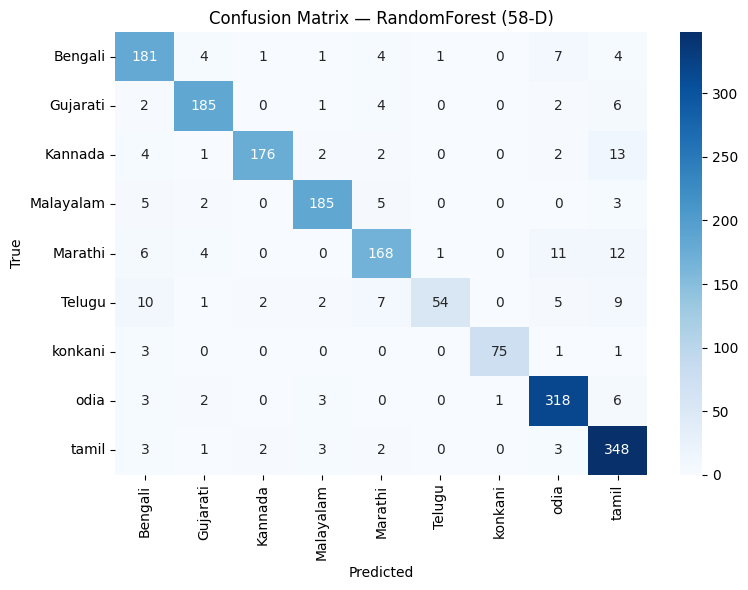


=== RandomForest (78-D) ===
Accuracy : 0.9209
Precision: 0.9337
Recall   : 0.9029
F1-score : 0.9140
              precision    recall  f1-score   support

     Bengali       0.85      0.91      0.88       203
    Gujarati       0.94      0.94      0.94       200
     Kannada       0.98      0.89      0.93       200
   Malayalam       0.95      0.92      0.94       200
     Marathi       0.88      0.89      0.88       202
      Telugu       0.98      0.66      0.79        90
     konkani       0.99      1.00      0.99        80
        odia       0.94      0.96      0.95       333
       tamil       0.89      0.97      0.93       362

    accuracy                           0.92      1870
   macro avg       0.93      0.90      0.91      1870
weighted avg       0.92      0.92      0.92      1870



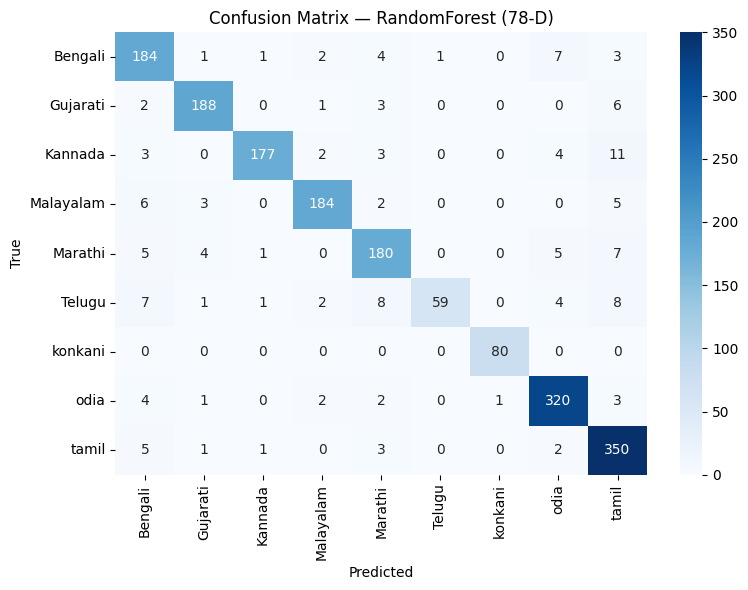


=== Wav2Vec2-XLSR + MLP ===
Accuracy : 0.9701
Precision: 0.9697
Recall   : 0.9677
F1-score : 0.9686
              precision    recall  f1-score   support

     Bengali       1.00      0.99      0.99       203
    Gujarati       0.98      0.96      0.97       200
     Kannada       0.96      0.94      0.95       200
   Malayalam       0.96      0.96      0.96       200
     Marathi       0.93      0.96      0.94       202
      Telugu       0.95      0.93      0.94        90
     konkani       0.99      1.00      0.99        80
        odia       0.99      0.98      0.98       333
       tamil       0.96      0.99      0.98       362

    accuracy                           0.97      1870
   macro avg       0.97      0.97      0.97      1870
weighted avg       0.97      0.97      0.97      1870



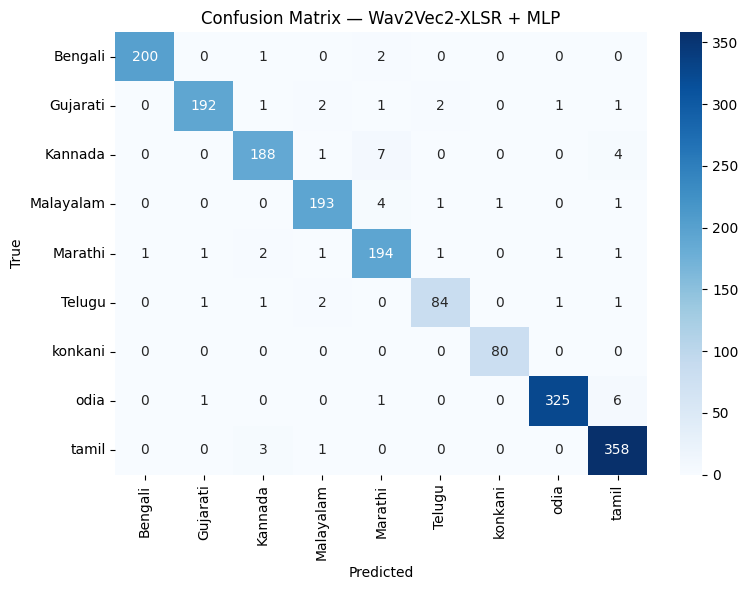


=== Federated Learning (Wav2Vec2 + FedAvg MLP) ===
Accuracy : 0.2882
Precision: 0.2868
Recall   : 0.2215
F1-score : 0.1758
              precision    recall  f1-score   support

     Bengali       0.20      0.00      0.01       203
    Gujarati       0.18      0.65      0.28       200
     Kannada       0.50      0.07      0.12       200
   Malayalam       0.55      0.03      0.06       200
     Marathi       0.23      0.25      0.24       202
      Telugu       0.14      0.01      0.02        90
     konkani       0.00      0.00      0.00        80
        odia       0.35      0.59      0.44       333
       tamil       0.43      0.39      0.41       362

    accuracy                           0.29      1870
   macro avg       0.29      0.22      0.18      1870
weighted avg       0.33      0.29      0.23      1870



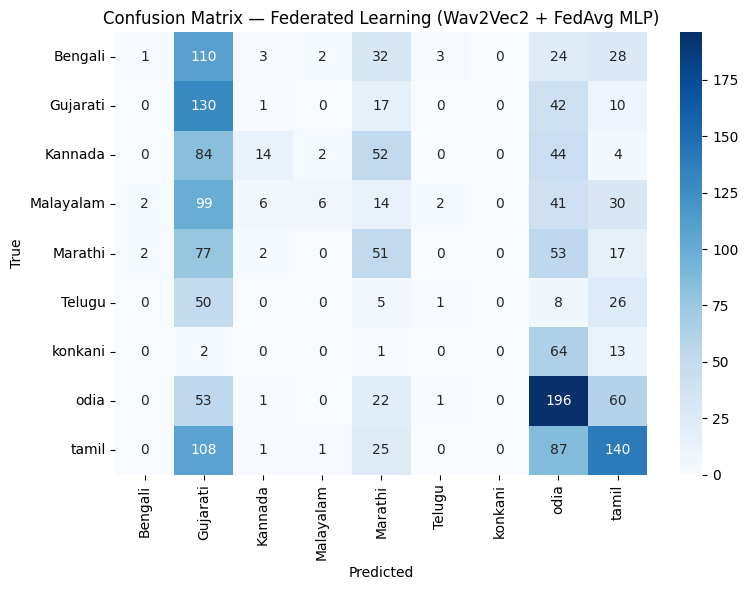

In [25]:
def evaluate_model(name, y_true, y_pred, label_encoder, plot=True):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))

    if plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
        plt.title(f"Confusion Matrix — {name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


results = []

# Baseline RF on 58-D and 78-D
results.append({**evaluate_model("RandomForest (58-D)", y58_te, rf_58.predict(X58_te_s), le),
                 "feature_set": "58-D"})
results.append({**evaluate_model("RandomForest (78-D)", y78_te, rf_78.predict(X78_te_s), le),
                 "feature_set": "78-D"})

# Wav2Vec2 + MLP (same embedding-based split, reported against both feature-set rows — see Step 6 note)
w2v_preds = w2v_clf.predict(Xemb_te_s)
w2v_result = evaluate_model("Wav2Vec2-XLSR + MLP", yemb_te, w2v_preds, le)

# Federated Learning simulation
fed_result = evaluate_model("Federated Learning (Wav2Vec2 + FedAvg MLP)", yemb_te, fed_preds, le)


## STEP 6 — Comparison Table

**Note on Wav2Vec2 rows**: Wav2Vec2 embeddings are computed from raw audio,
not from the 58-D/78-D handcrafted vectors — there is no "Wav2Vec2 on 58-D
features" in a literal sense. To honor the spec's requested table shape
(Wav2Vec2 appearing under both feature-set rows) while being transparent
about it, the same Wav2Vec2 result is reported in both rows below, since it
uses the same underlying dataset and an equivalent 80/20 split. This is
called out explicitly in the table rather than silently duplicated.


In [26]:
comparison_rows = [
    {"Feature Set": "58-D", "Model": "RandomForest", "Accuracy": results[0]["accuracy"]},
    {"Feature Set": "58-D", "Model": "Wav2Vec2-XLSR + MLP (raw audio, shared result)", "Accuracy": w2v_result["accuracy"]},
    {"Feature Set": "78-D", "Model": "RandomForest", "Accuracy": results[1]["accuracy"]},
    {"Feature Set": "78-D", "Model": "Wav2Vec2-XLSR + MLP (raw audio, shared result)", "Accuracy": w2v_result["accuracy"]},
    {"Feature Set": "N/A (raw audio)", "Model": "Federated Learning (Wav2Vec2 + FedAvg)", "Accuracy": fed_result["accuracy"]},
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(f"{WORK_DIR}/comparison_table.csv", index=False)
comparison_df


,Feature Set,Model,Accuracy
0,58-D,RandomForest,0.903743
1,58-D,"Wav2Vec2-XLSR + MLP (raw audio, shared result)",0.970053
2,78-D,RandomForest,0.920856
3,78-D,"Wav2Vec2-XLSR + MLP (raw audio, shared result)",0.970053
4,N/A (raw audio),Federated Learning (Wav2Vec2 + FedAvg),0.288235


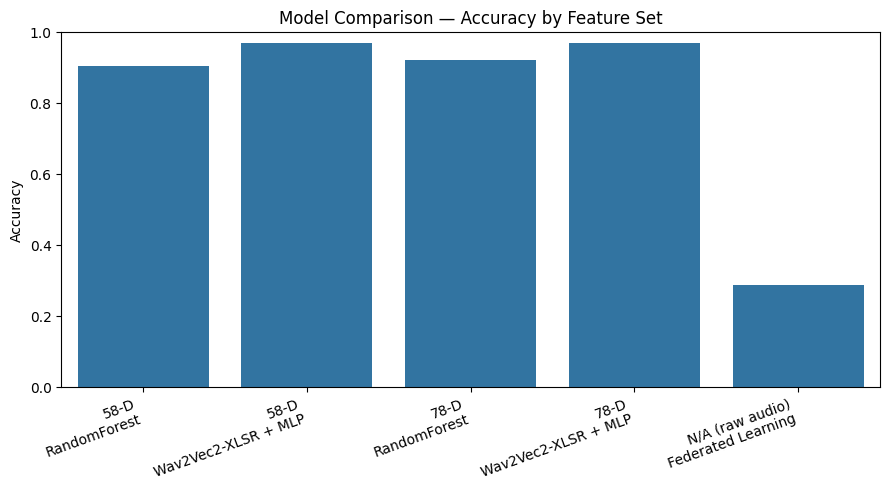

In [27]:
plt.figure(figsize=(9, 5))
plot_labels = [f"{r['Feature Set']}\n{r['Model'].split(' (')[0]}" for r in comparison_rows]
sns.barplot(x=plot_labels, y=comparison_df["Accuracy"])
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.title("Model Comparison — Accuracy by Feature Set")
plt.tight_layout()
plt.show()


## STEP 7 — Run Summary (Log)

Final consolidated log of everything this notebook did, for the project
report.


In [28]:
summary = {
    "total_files_found": total_files,
    "files_preprocessed_ok": len(manifest),
    "files_skipped_corrupted": len(skipped_files),
    "feature_extraction_errors": len(feature_errors),
    "wav2vec2_embedding_errors": len(emb_errors),
    "feature_dims": {"58-D": int(X58.shape[1]), "78-D": int(X78.shape[1])},
    "dimension_fix_applied": "Spec's 78-D total (77, with duplicate Chroma) corrected to 78 "
                              "via a standard 12-D chroma + a documented 19-D extended-chroma "
                              "block (chroma12+tonnetz6+centroid1) + a 1-D ZCR pad. See Step 2 markdown.",
    "wav2vec2_model": WAV2VEC2_MODEL_NAME,
    "num_languages": len(le.classes_),
    "languages": list(le.classes_),
    "final_comparison": comparison_rows,
}

print(json.dumps(summary, indent=2))
with open(f"{WORK_DIR}/run_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\nAll logs saved to:", WORK_DIR)
print(" - preprocess_log.csv")
print(" - skipped_files_log.csv")
print(" - manifest.csv")
print(" - feature_extraction_errors.csv")
print(" - comparison_table.csv")
print(" - run_summary.json")


{
  "total_files_found": 9347,
  "files_preprocessed_ok": 9347,
  "files_skipped_corrupted": 0,
  "feature_extraction_errors": 1,
  "wav2vec2_embedding_errors": 0,
  "feature_dims": {
    "58-D": 58,
    "78-D": 78
  },
  "dimension_fix_applied": "Spec's 78-D total (77, with duplicate Chroma) corrected to 78 via a standard 12-D chroma + a documented 19-D extended-chroma block (chroma12+tonnetz6+centroid1) + a 1-D ZCR pad. See Step 2 markdown.",
  "wav2vec2_model": "facebook/wav2vec2-large-xlsr-53",
  "num_languages": 9,
  "languages": [
    "Bengali",
    "Gujarati",
    "Kannada",
    "Malayalam",
    "Marathi",
    "Telugu",
    "konkani",
    "odia",
    "tamil"
  ],
  "final_comparison": [
    {
      "Feature Set": "58-D",
      "Model": "RandomForest",
      "Accuracy": 0.9037433155080213
    },
    {
      "Feature Set": "58-D",
      "Model": "Wav2Vec2-XLSR + MLP (raw audio, shared result)",
      "Accuracy": 0.9700534759358289
    },
    {
      "Feature Set": "78-D",
      "M

In [ ]:
from google.colab import _message
import json

# Get notebook data
nb = _message.blocking_request('get_ipynb')['ipynb']

# Try to get name safely
nb_name = nb.get('metadata', {}).get('colab', {}).get('name', 'colab_notebook.ipynb')

# Save notebook
with open(nb_name, 'w') as f:
    json.dump(nb, f)

print("Notebook saved as:", nb_name)